In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("data.csv", sep=";", encoding="iso-8859-1")

In [3]:
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,160,100,84,18,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,137,75,60,20,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,130,80,102,20,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,139,94,88,20,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,91,67,93,18,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


## Description of each column from the dataset 
* **Group:** Type of emergency department [1= Local ED 3th Degree, 2= Regional ED 4th Degree]
* **Sex:** Sex of the patient [1= Female, 2=Male]
* **Age:** Age of the patient
* **Patients number per hour:** Number of patients arriving at the emrgency department per hour at the time of this patient's admission
* **Arrival mode:** Type of transportation to the hospital [1= Walking, 2=Public Ambulance, 3=Private Vehicle, 4 = Private Ambulance, 5,6,7= Other]
* **Injury:** Whether The patient is injured or not [1=No, 2=Yes]
* **Chief_complain:** The Patient's complain
* **Mental:** The mental state of the patient [1=Alert, 2= Verbal Response, 3= Pain Response, 4=Unresponse]
* **Pain:** Whether the patient has pain [1= Yes, 0= No]
* **NRS_pain:** Nurse's assesment of pain for the patient [0= No pain,...,10= High Pain]
* **SBP:** Systolic Blood Pressure
* **DBP:** Diastolic Blood Pressure
* **HR:** Heart Rate
* **RR:** Respiratory Rate
* **BT:** Body Temperature
* **Saturation:** Oxygen Saturation
* **KTAS_RN:** Triage level assigned by a nurse (using the Korean Triage and Acuity Scale)
* **Diagnosis in ED:** Final Diagnosis made in the emergency department
* **Disposition:** Outcome of the visit [1= Dischange, 2= Admission to ward, 3= Admission to ICU, 4= Discharge, 5=Transfer, 6=Death, 7=Surgery]
* **KTAS_expert:** Triage level assigned by an expert
* **Error_group:** Categorization of triage errors (difference between nurse nad expert assessment)
* **Length of stay_min:** Total time (in minutes) the patient stayed in the emergency department
* **KTAS duration_min:** Time (in minutes) taken to complete the KTAS triage process.
* **mistriage:** Binary indicator showing whether the patient was mis-triaged (incorrect triage decision)


### KTAS Levels and Time Objectives
* **Level 1 (Resuscitation):** Immediate intervention
* **Level 2 (Emergent):** Within 30 min
* **Level 3 (Urgent):** Within 60 min
* **Level 4 (Less Urgent):** Within 90 min
* **Level 5 (Non-urgent):** Within 120 min

[1,2,3 = Emergency, 4,5= Non-Emergency

# 1. Elimination of data leakage
We need to remove columns that contain information known only after the patient has undergone triage

## Columns that we need to remove:
* Group
* Diagnosis in ED
* Disposition
* KTAS_RN (we want to make sure that the model will make decisions independently)
* Error_group
* mistriage
* Length of stay_min
* KTAS duration_min

In [4]:
df = df.drop(["Group", "Diagnosis in ED", "Disposition", "KTAS_RN", "Error_group", "mistriage", "Length of stay_min", "KTAS duration_min"], axis=1)

In [5]:
df.columns

Index(['Sex', 'Age', 'Patients number per hour', 'Arrival mode', 'Injury',
       'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR',
       'RR', 'BT', 'Saturation', 'KTAS_expert'],
      dtype='str')

# 2. Fixing data types (converting from text to numbers)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Sex                       1267 non-null   int64
 1   Age                       1267 non-null   int64
 2   Patients number per hour  1267 non-null   int64
 3   Arrival mode              1267 non-null   int64
 4   Injury                    1267 non-null   int64
 5   Chief_complain            1267 non-null   str  
 6   Mental                    1267 non-null   int64
 7   Pain                      1267 non-null   int64
 8   NRS_pain                  1267 non-null   str  
 9   SBP                       1267 non-null   str  
 10  DBP                       1267 non-null   str  
 11  HR                        1267 non-null   str  
 12  RR                        1267 non-null   str  
 13  BT                        1267 non-null   str  
 14  Saturation                579 non-null    str  
 15

Columns Chief_complain, NRS_pain, SBP, DBP, HR, RR, BT and Saturation have the Dtype str.

For the column Chief_complain we are going to leave top 10 complains and the rest is going to be marked as "Other"

For other str columns we will convert it to a numerical format

In [7]:
#Chief_complain 
top_10 = df["Chief_complain"].value_counts().nlargest(10).index
top_10

Index(['abd pain', 'dyspnea', 'dizziness', 'fever', 'ant. chest pain',
       'Open Wound', 'headache', 'epigastric pain', 'mental change',
       'general weakness'],
      dtype='str', name='Chief_complain')

In [8]:
df["Chief_complain"] = df["Chief_complain"].where(df["Chief_complain"].isin(top_10), "Other")

In [9]:
#converting str values to 0/1 values
df = pd.get_dummies(df, columns=["Chief_complain"], prefix="C")

In [10]:
#converting columns NRS_pain, SBP, DBP, HR, RR, BT and Saturation to a numerical format
cols_to_fix = ["NRS_pain", "SBP", "DBP", "HR", "RR", "BT", "Saturation"]

#errors='coerce' : If a value can be converted to a number, convert it. 
#If a value cannot be converted (it raises an error), replace it with NaN (Not a Number).

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Handling the missing values 

In [11]:
df.isnull().sum()

Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Mental                        0
Pain                          0
NRS_pain                    556
SBP                          25
DBP                          29
HR                           20
RR                           22
BT                           18
Saturation                  697
KTAS_expert                   0
C_Open Wound                  0
C_Other                       0
C_abd pain                    0
C_ant. chest pain             0
C_dizziness                   0
C_dyspnea                     0
C_epigastric pain             0
C_fever                       0
C_general weakness            0
C_headache                    0
C_mental change               0
dtype: int64

## Group 1:

SBP, DBP, HR, RR, BT- there are very few missing values (28-29). We are going to replace missing values with median.

## Group 2:

Saturation- 697 missing values. That may have been because the nurse thought that the measurement is unnecessary (which may be a predictor). New column will be created to tell the model that a measurement was missing.

## Group 3:

NRS_pain- 556 missing values likely mean that the value in the Pain column is 0. There was no point in specyfing pain if there was none measured. However, patient may have been unresponsive or in high pain (Mental=3 or Mental=4) and due to that there's no data about their pain. We will add another column that will tell the model that the level of pain was unmeasured.

Next, we will replace the missing values in NRS_pain column with 0 (if the value in the Pain column is 0) and then drop column Pain since it's no longer needed (NRS_pain and new column (pain_unmeasured) has all the important information)

In [12]:
#group 1
df["SBP"] = df["SBP"].fillna(df["SBP"].median())
df["DBP"] = df["DBP"].fillna(df["DBP"].median())
df["HR"] = df["HR"].fillna(df["HR"].median())
df["RR"] = df["RR"].fillna(df["RR"].median())
df["BT"] = df["BT"].fillna(df["BT"].median())

In [13]:
#group 2
df["Saturation_is_missing"] = df["Saturation"].isnull().astype(int)
#we will filmm missing values with median so that the model does not crash
df["Saturation"] = df["Saturation"].fillna(df["Saturation"].median())

In [14]:
#group 3
df["pain_unmeasurable"] = ((df["Mental"]>=3)&(df["Pain"]==0)).astype(int)
df.loc[df["Pain"] == 0, "NRS_pain"] = 0

In [15]:
df.isnull().sum()

Sex                         0
Age                         0
Patients number per hour    0
Arrival mode                0
Injury                      0
Mental                      0
Pain                        0
NRS_pain                    3
SBP                         0
DBP                         0
HR                          0
RR                          0
BT                          0
Saturation                  0
KTAS_expert                 0
C_Open Wound                0
C_Other                     0
C_abd pain                  0
C_ant. chest pain           0
C_dizziness                 0
C_dyspnea                   0
C_epigastric pain           0
C_fever                     0
C_general weakness          0
C_headache                  0
C_mental change             0
Saturation_is_missing       0
pain_unmeasurable           0
dtype: int64

We still have 3 missing values in NRS_pain column. In that case we can't replace it with 0, because we know that they feel pain. We are going to replace these missing values with typical pain level (median)

In [16]:
df["NRS_pain"] = df["NRS_pain"].fillna(df["NRS_pain"].median())

In [17]:
df.isnull().sum()

Sex                         0
Age                         0
Patients number per hour    0
Arrival mode                0
Injury                      0
Mental                      0
Pain                        0
NRS_pain                    0
SBP                         0
DBP                         0
HR                          0
RR                          0
BT                          0
Saturation                  0
KTAS_expert                 0
C_Open Wound                0
C_Other                     0
C_abd pain                  0
C_ant. chest pain           0
C_dizziness                 0
C_dyspnea                   0
C_epigastric pain           0
C_fever                     0
C_general weakness          0
C_headache                  0
C_mental change             0
Saturation_is_missing       0
pain_unmeasurable           0
dtype: int64

Now we no longer have any missing values

In [18]:
df = df.drop(["Pain"], axis=1)

In [19]:
df.head()

,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_expert,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable
0,2,71,3,3,2,1,2.0,160.0,100.0,84.0,18.0,36.6,100.0,4,False,True,False,False,False,False,False,False,False,False,False,0,0
1,1,56,12,3,2,1,2.0,137.0,75.0,60.0,20.0,36.5,98.0,5,False,True,False,False,False,False,False,False,False,False,False,1,0
2,1,68,8,2,2,1,2.0,130.0,80.0,102.0,20.0,36.6,98.0,5,False,True,False,False,False,False,False,False,False,False,False,0,0
3,2,71,8,1,1,1,3.0,139.0,94.0,88.0,20.0,36.5,98.0,5,False,True,False,False,False,False,False,False,False,False,False,1,0
4,2,58,4,3,1,1,3.0,91.0,67.0,93.0,18.0,36.5,98.0,5,False,True,False,False,False,False,False,False,False,False,False,1,0


The last thing we have to do (in the process of data cleaning) is to create dummies for the column Arrival mode. If we won't do that, the model may think that for example number 4 is "better" or "bigger" than 1 (in that case it's not true, because "Private Ambulance" is not "better" or "bigger" than walking). Apart from that, this column contains values from 1 to 7, where 5,6,7 are "Other" types of transportations, so first we have to merge 5,6 and 7 in one category.

We won't replace the Mental column with dummies because in that case the number is significant. The larger the number, the worser patient's state

In [20]:
#merging 5,6,7 into one category
df["Arrival mode"] = df["Arrival mode"]. replace({6: 5, 7: 5})

In [21]:
df["Arrival mode"].value_counts()

Arrival mode
3    753
2    266
4    155
1     79
5     14
Name: count, dtype: int64

In [22]:
df = pd.get_dummies(df, columns=["Arrival mode"], prefix="Arrival", drop_first=True)

# 4. Feature Engineering

In [23]:
#patient is hypotensive (has low blood pressure)
df["is_hypotensive"] =((df["SBP"] < 90) | (df["DBP"] < 60)).astype(int)

#patient is hypertensive (has high blood pressure)
df["is_hypertensive"] = ((df["SBP"] > 140) | (df["DBP"] > 90)).astype(int)

#patient has fever
df["has_fever"] = (df["BT"] > 38.0).astype(int)

#how saturated the blood is with oxygen (compared to its total capacity,
#not the total absolute amount of oxygen)
df["low_oxygen"] = (df["Saturation"] < 94).astype(int)

#patitent has tachycardia 
df["tachycardia"] = (df["HR"] > 100).astype(int)

#patitent has bradycardia 
df["bradycardia"] = (df["HR"] < 60).astype(int)

#shock index 
df["shock_index"] = df["HR"] / df["SBP"]

#mean arterial pressure (MAP)
df["map"] = (df["SBP"]+2*df["DBP"])/3

# 5. Data Analysis & Data Visualisation

## Basic information

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sex                       1267 non-null   int64  
 1   Age                       1267 non-null   int64  
 2   Patients number per hour  1267 non-null   int64  
 3   Injury                    1267 non-null   int64  
 4   Mental                    1267 non-null   int64  
 5   NRS_pain                  1267 non-null   float64
 6   SBP                       1267 non-null   float64
 7   DBP                       1267 non-null   float64
 8   HR                        1267 non-null   float64
 9   RR                        1267 non-null   float64
 10  BT                        1267 non-null   float64
 11  Saturation                1267 non-null   float64
 12  KTAS_expert               1267 non-null   int64  
 13  C_Open Wound              1267 non-null   bool   
 14  C_Other            

* 1267 rows, 35 columns. No missing values

In [25]:
df.describe()

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_expert,Saturation_is_missing,pain_unmeasurable,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.521705,54.423836,7.519337,1.192581,1.105762,2.310182,133.576953,79.785320,83.932123,19.515391,36.579479,97.561168,3.265983,0.550118,0.030781,0.042620,0.367009,0.025257,0.025257,0.157853,0.037885,0.652795,97.715864
std,0.499726,19.725033,3.160563,0.394482,0.447768,2.295524,27.009758,14.979755,16.513917,2.000089,0.541899,2.956772,0.885803,0.497678,0.172793,0.202079,0.482179,0.156965,0.156965,0.364747,0.190993,0.182955,17.821968
min,1.000000,16.000000,1.000000,1.000000,1.000000,0.000000,50.000000,31.000000,32.000000,14.000000,35.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.228571,38.666667
25%,1.000000,37.000000,5.000000,1.000000,1.000000,0.000000,115.000000,70.000000,72.000000,18.000000,36.200000,98.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.523940,85.000000
50%,2.000000,57.000000,7.000000,1.000000,1.000000,3.000000,130.000000,80.000000,82.000000,20.000000,36.500000,98.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636364,96.666667
75%,2.000000,71.000000,10.000000,1.000000,1.000000,4.000000,150.000000,90.000000,96.000000,20.000000,36.800000,98.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.742262,109.166667
max,2.000000,96.000000,17.000000,2.000000,4.000000,10.000000,275.000000,160.000000,148.000000,30.000000,41.000000,100.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.593407,194.333333


* **Sex.** Mean is 1.52. The split between Female (1) and Male (2) is nearly 50/50.
* **Age.** The average patient is approximately 54 years old. The range is broad (16 to 96) but the 25th percentiles starts at 37, which means its mostly adult/elderly population.
* **Patients number per hour.** On average patients arrive at the time where 7.5 patients are admitted per hour. At peak times (max), this hits 17 patients per hour, which could indicate periods of high stress on staff.
* **Injury.** Only 19% of cases are injury-related (mean: 1.19). The majority of patients are seeking help for non-traumatic medical complaints.
* **Mental.** Most patients are stable. A mean of 1.10 (where 1 is "Alert") and a 75th percentile of 1.00 shows that over 75% patients are fully alert upon arrival
* **NRS_pain.** The average pain score is 2.31/10. However, the standard deviation (std: 2.3) and max of 10 indicate significant variability- some patients are in extreme distress while many report zero pain.
* **Vitals Stability:**
    * **Blood Pressure.** The mean SBP (135.58) is slightly elevated. Besides that 36.7% of the patients is hypertensive, while only 4.2% are hypotensive. Max value of SBP is 275 (which is critically high), Min value is 50 (which is extremaly low).
    * **Oxygen (Saturation).** The mean is high (97.56%), but the minimum of 20 is a critical outlier <span style="color:red"><-- we have to check it</span>
    * **Heart Rate (HR).** Tachycardia is present in 15.8% of patients, while bradycardia in 3.8%.
    * **Fever.** Only 2.5% of patients have fever
* **Triage**
    * The **KTAS_expert** mean is 3.27. The median and 75th percentile are between 3 and 4, most of the patients have "urgent" to "less urgent" cases. Truly critical cases (Level 1) are in the minority.


In [26]:
df[df["Saturation"] < 60]

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_expert,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable,Arrival_2,Arrival_3,Arrival_4,Arrival_5,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
1148,2,77,7,1,1,0.0,130.0,80.0,56.0,20.0,36.2,20.0,3,False,False,False,False,True,False,False,False,False,False,False,0,0,True,False,False,False,0,0,0,1,0,1,0.430769,96.666667


Patient mental state was classified as 1 (Alert) what contradicts with low Saturation. We can assume that is a data entry error. We have to delete this row because it might mislead model.

In [27]:
df = df[df["Saturation"] != 20]

In [28]:
df[df["SBP"] < 55]

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_expert,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable,Arrival_2,Arrival_3,Arrival_4,Arrival_5,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
122,1,50,9,1,3,0.0,50.0,33.0,37.0,28.0,36.5,98.0,1,False,True,False,False,False,False,False,False,False,False,False,1,1,False,True,False,False,1,0,0,0,0,1,0.74,38.666667
123,1,50,9,1,3,0.0,50.0,33.0,37.0,28.0,36.5,98.0,1,False,True,False,False,False,False,False,False,False,False,False,1,1,False,True,False,False,1,0,0,0,0,1,0.74,38.666667


Patients with extremaly low blood pressure. These are extreme but valuable values.

In [29]:
df[df["SBP"] > 260]

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_expert,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable,Arrival_2,Arrival_3,Arrival_4,Arrival_5,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
810,2,34,4,1,1,0.0,275.0,154.0,120.0,28.0,38.1,98.0,2,False,False,False,False,False,True,False,False,False,False,False,1,0,False,True,False,False,0,1,1,0,1,0,0.436364,194.333333


Patient with extremaly high blood pressure. This record is also extreme but valuable. 

## Distributions of numerical variables

In [30]:
import matplotlib.pyplot as plt

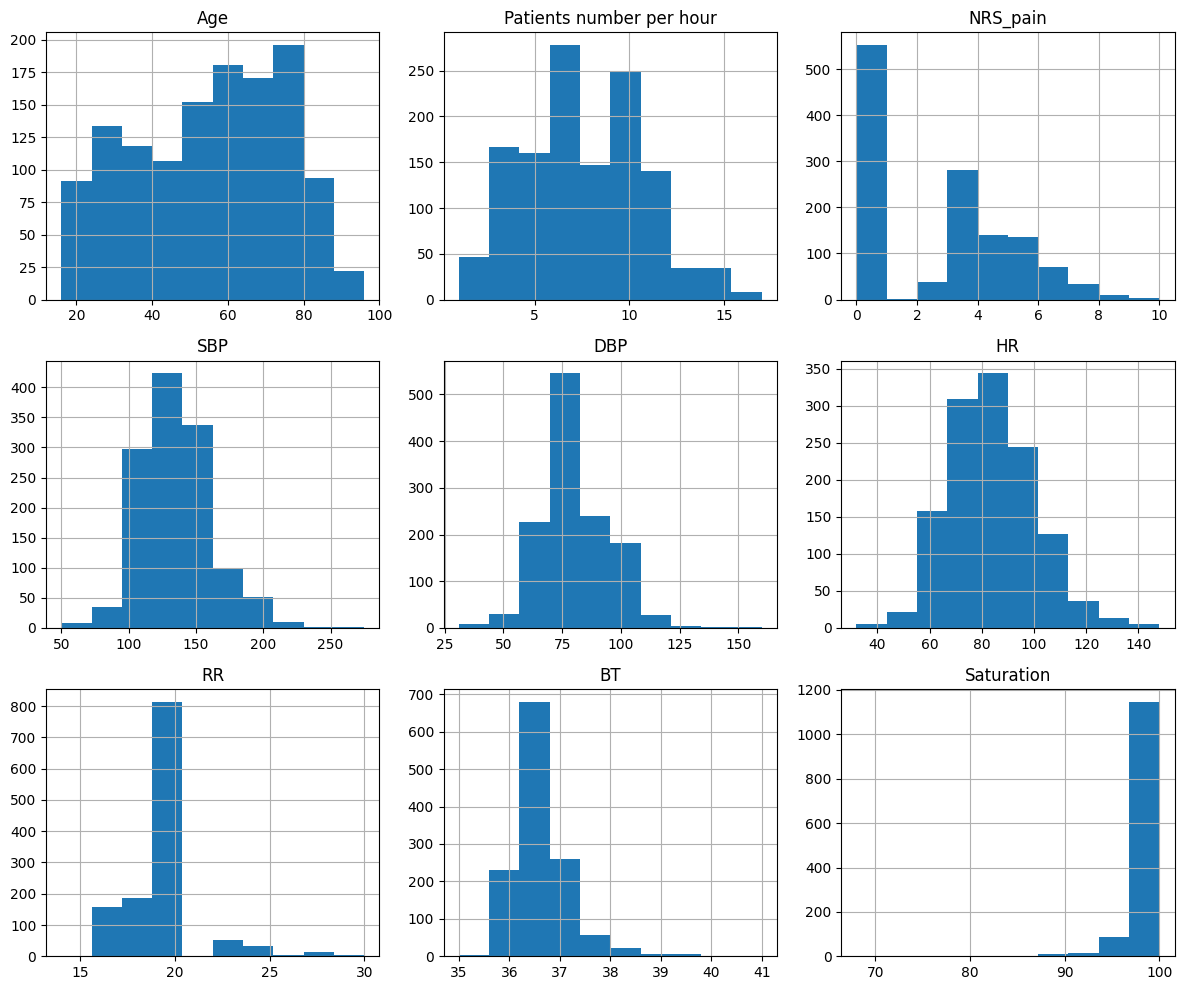

In [31]:
num_cols = ['Age', 'Patients number per hour', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

### Age:
* Most patients are aged 50 to 80 years old. There are very few patients older than 90 years old.
### Patients number per hour 
* Most of the times we could expect about 7 or 10 patients per hour (which match up with median and mean which range around 7)

### NRS_pain
* Most patients have pain level = 0 (or their pain level couldn't be measured). Very few patients have pain level greater than 8.

### SBP
* Most patients SBP varies around 125, but there are also a lot of cases where patient is hypertensive (SBM>140). Extremaly high blood pressure is rare, just as extremaly low blood pressure.

### DBP
* Most patients DBP is around 75 which is normal. But there are also some cases with hypertensive DBP and very few cases of hypotension (that match up with SBP values)

### HR 
* Most patients have normal heart rate although some have tachycardia

### RR
* Normal range of respiratory rate is 12-20. Some patients are above that, but most of them have normal value of respiratory rate.

### BT
* Most patients have normal body temperature, few of them may have fever.

### Saturation 
* The vast majority of patients have safe saturation value, although there are some cases of dangerously low saturation. 

## Correlation

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

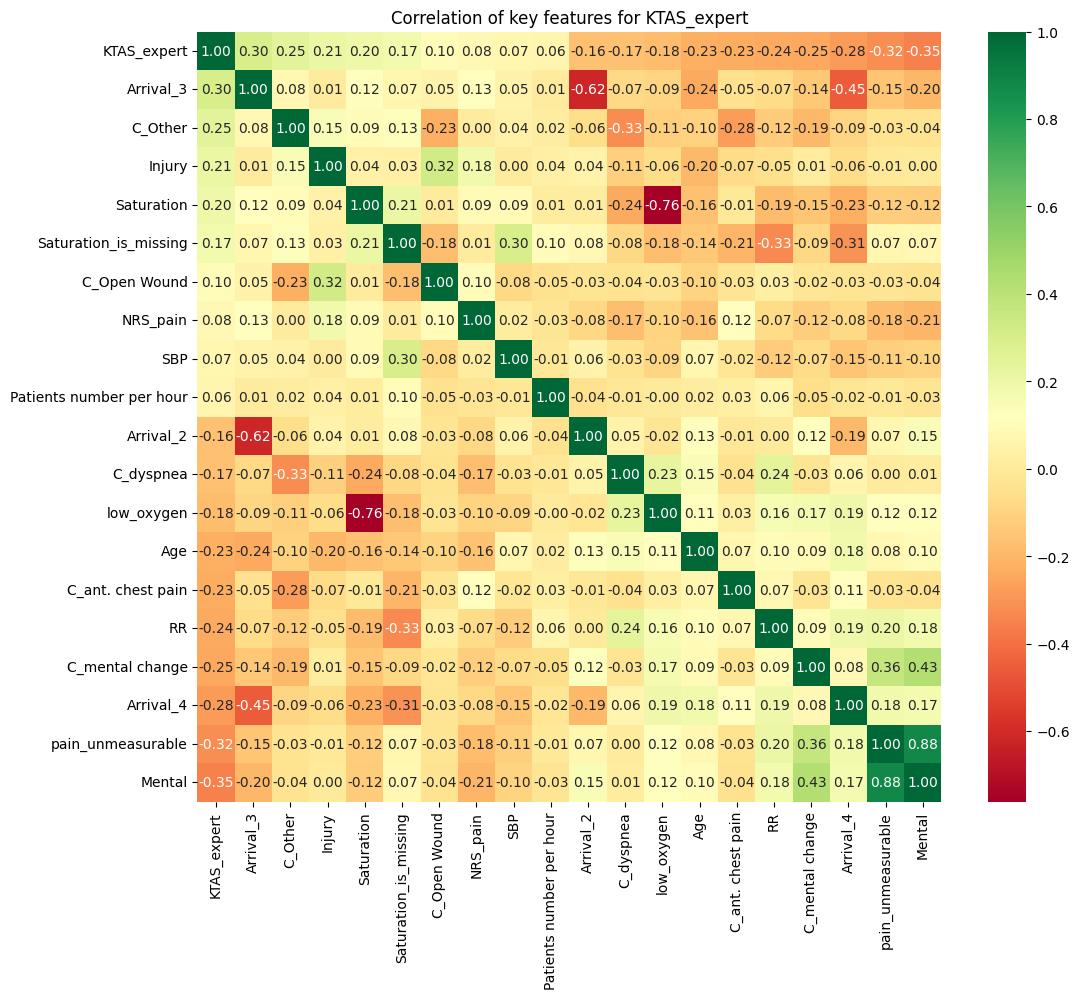

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

#we are choosing only the columns with the highest correlation to KTAS_expert
top_corr_features = df.corr()["KTAS_expert"].sort_values(ascending=False).head(10).index
top_corr_features = top_corr_features.append(df.corr()["KTAS_expert"].sort_values(ascending=False).tail(10).index)

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Correlation of key features for KTAS_expert")
plt.show()

### The strongest correlations 
#### Positive correlations
1. **Mental and pain_unmeasurable (0.88).** Very strong dependence. The worst the state of consciousness (Mental), the more often the pain is impossible to measure.
2. **Mental and C_mental change (0.43).** Patients with the Chief Complaint of "mental change" actually have worse scores on the Mental scale. 
3. **pain_unmeasurable and C_mental change (0.36).** Patients with the Chief Complaint of "mental change" often goes with inability to reliably assess pain. 
4. **C_open wound and Injury (0.32).** Logical connection. Open wounds are classified as injuries.
5. **SBP and Saturation_is_missing (0.30).** This correlations suggests that patients with higher blood pressure (SBP) were more likely to have their saturation measurement missed.
6. **Arrival_3 and KTAS_expert (0.30).** Arrival_3 is a private vehicle. A positive correlation with KTAS_expert indicates that such patients receive higher KTAS numbers (4 or 5), meaning they are less severe cases (Unassisted arrival to the ED is a strong predictor of stable health status)
#### Negative correlations
1. **low_oxygen and Saturation (-0.76).** The lower the saturation, the more often the low_oxygen flag lights up.
4. **Mental and KTAS_expert (-0.35).** The higher the Mental value (worse condition), the lower the KTAS_expert number. 
5. **RR and Saturation_is_missing (-0.33).** The higher the respiratory rate (RR), the less frequently saturation is deficient. Medical personnel rightly prioritize oxygen measurement in patients who are experiencing breathing difficulties. 
7. **pain_unmeasurable and KTAS_expert (-0.32).** If the pain is unmeasurable (because the patient is, for example, unconscious), the KTAS_expert number drops drastically towards 1 (hightest priority).

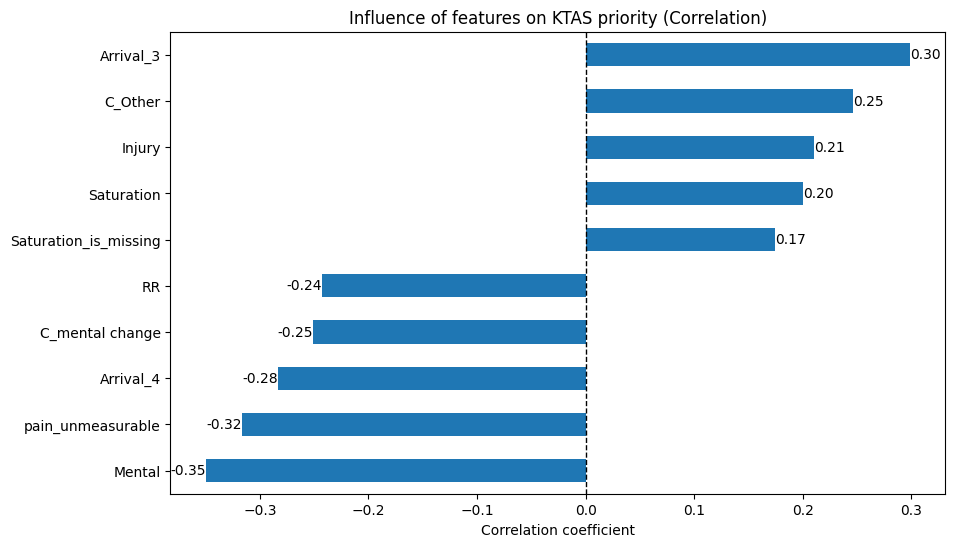

In [34]:
plt.figure(figsize=(10, 6))

correlations = df.corr()["KTAS_expert"].drop("KTAS_expert").sort_values()

top_corrs = pd.concat([correlations.head(5), correlations.tail(5)])

ax = top_corrs.plot(kind="barh")

plt.title("Influence of features on KTAS priority (Correlation)")
plt.xlabel("Correlation coefficient")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)

for i, v in enumerate(top_corrs):
    ax.text(v, i, f"{v:.2f}", va='center',
            ha='left' if v > 0 else 'right')

plt.show()

### Influence of features on KTAS priority - interpretation
1. **Arrival_3 (0.30).** The strongest positive predictor. If a patient was able to drive themselves or received a lift from their family, they are statistically in better shape than those who, for example, came by ambulance. This is a clear indication of a higher KTAS_expert number.
2. **C_Other (0.25).** If the reason for the visit isn't in the "TOP 10", it's usually less urgent.
3. **Injury (0.21).** Although injuries are  painful, they are not as immediately life-threatening as a heart attack or stroke. 
4. **Saturation (0.20).** The higher the saturation (closer to 100%), the safer the patient is. High oxygen levels are a stron argument that the patient can safely wait. 
5. **Saturation_is_missing (0.17).** If the medical staff has determined that the patient's condition is so good that there is no need to measure it, it usually results in a higher KTAS_expert number.
6. **RR (-0.24).** The higher the respiratory rate (the patient breathes rapidly), the lower the KTAS number. Rapid breathing may be a sign of some serious problems which need to immediately be taken care of.
7. **C_mental change (-0.25).** Reporting that patients acts strangely is a red flag. Such individuals are automatically placed in high-priority groups.
8. **Arrival_4 (-0.28).** The negative correlation suggests that patients transported by a private ambulance are usually in worse condition than those who came on their own. 
9. **pain_unmeasurable (-0.32).** If a patients is in such state that he cannot administer pain, it's a very strong alarm signal.
10. **Mental (-0.35).** The higher the Mental score (unresposiveness) the lower (more urgent) the KTAS LEVEL. 

## Target variable Analysis (KTAS_expert)

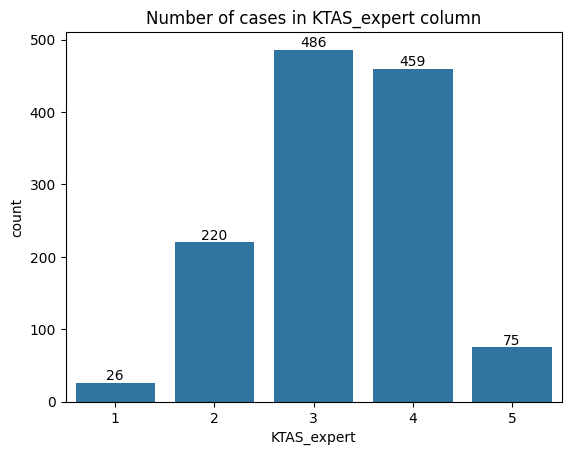

In [35]:
ax = sns.countplot(x='KTAS_expert', data=df)
ax.bar_label(ax.containers[0])
plt.title("Number of cases in KTAS_expert column")
plt.show()

### Normal distribution 
The most patients are in the middle (KTAS 3 and KTAS 4) and the fewest are the extremes (KTAS 1 and KTAS 5).
- KTAS 3 and 4 (945 patients): These constitute approximately 75% of the entire dataset. The model will probably be an expert on them because it has a lot of examples to learn from.
- KTAS 1 (26 patients): This represents only 2% of the data. The model may tend to miss these patients because it is statistically more profitable to guess KTAS 3 or 4.
- KTAS 5 (75 patients): This represents 6% of the data. These are non-emergency patients. 

## Boxplots

In [36]:
def get_outliers(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return x[(x < lower) | (x > upper)].values

### SBP (Systolic Blood Pressure)

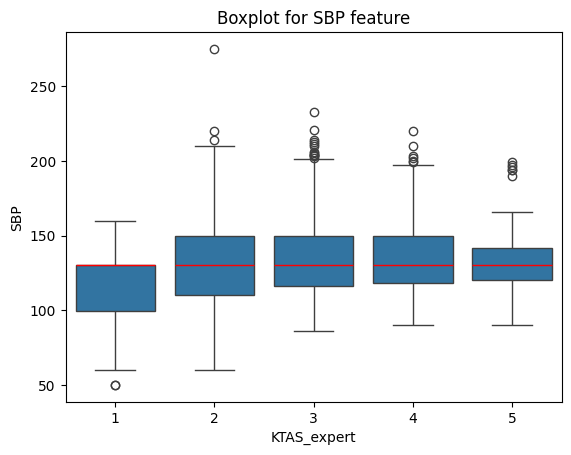

In [37]:
sns.boxplot(x="KTAS_expert", y='SBP', data=df, medianprops={"color": "red"})
plt.title("Boxplot for SBP feature")
plt.show()

In [38]:
stats = df.groupby("KTAS_expert")["SBP"].describe()
outliers = df.groupby("KTAS_expert")["SBP"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min     25%    50%    75%    max  \
KTAS_expert                                      
1            50.0   99.25  130.0  130.0  160.0   
2            60.0  110.00  130.0  150.0  275.0   
3            86.0  116.00  130.5  150.0  233.0   
4            90.0  118.00  130.0  150.0  220.0   
5            90.0  120.00  130.0  142.0  199.0   

                                                      outliers  
KTAS_expert                                                     
1                                                 [50.0, 50.0]  
2                                        [214.0, 275.0, 220.0]  
3            [214.0, 210.0, 204.0, 202.0, 211.0, 205.0, 204...  
4                   [200.0, 199.0, 202.0, 203.0, 210.0, 220.0]  
5                   [196.0, 190.0, 194.0, 199.0, 194.0, 197.0]  


1. **Median stability:**
    * The median for all groups (KTAS 1 to 5) hovers around 130 mmHg.
    * The "average" patient in each group has nearly identical blood pressure. The model cannot rely solely od SBP to distinguish an urgent patient from a stable one. SBP only becomes an alarm signal when it deviates from the norm.
2. **KTAS 1:**
    * Minimum: A drop to around 50 mmHg
    * Outliers: Low values are considered outliers, suggesting that even in the critical group, such profound hypotension is rare but extremaly significant.
    * In KTAS  1, blood pressure is stretched downward. If SBP drops below 90 (which is considered dangerously low blood pressure), the likelihood of falling into this group increases dramatically.
3. **KTAS 2:**
    * Maximum value reaches as high as 275 mmHg.
    * This group includes patients with extremaly high blood pressure. While KTAS 1 concerns low blood pressure, KTAS 2 concerns life-threatening cases due to hypertension.
4. **KTAS 3 and KTAS 4:**
    * Outliers (above 200mmHg): There is a large number of patients with blood pressure above 200 in groups 3 and 4.
    * High blood pressure alone does not warrant top priority if the patient has no other symptoms.
5. **KTAS 5:**
    * Here, the boxplot's "whiskers" are the shortest. Minimum values do not fall below 90mmHg
    * Patients in the least severe condition have stable circulation. There are no cases with low blood pressure.

### HR (Heart Rate)

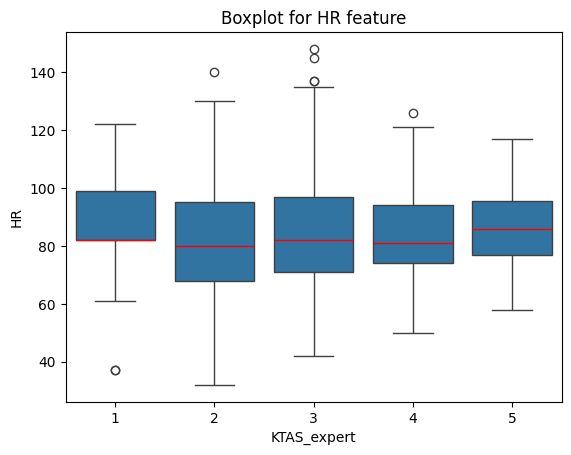

In [39]:
sns.boxplot(x="KTAS_expert", y="HR", data=df, medianprops={"color": "red"})
plt.title("Boxplot for HR feature")

plt.show()

In [40]:
stats = df.groupby("KTAS_expert")["HR"].describe()
outliers = df.groupby("KTAS_expert")["HR"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min   25%   50%    75%    max                      outliers
KTAS_expert                                                              
1            37.0  82.0  82.0  99.00  122.0                  [37.0, 37.0]
2            32.0  68.0  80.0  95.25  140.0                       [140.0]
3            42.0  71.0  82.0  97.00  148.0  [145.0, 148.0, 137.0, 137.0]
4            50.0  74.0  81.0  94.00  126.0                       [126.0]
5            58.0  77.0  86.0  95.50  117.0                            []


1. **Median:**
   * The median HR for all groups is similiar, fluctuating around 80-86 beats per minute.
   * Most patients, regardless of whether they are in severe or mild condition, have heart rates within the normal range (60-100). This means that the model cannot make decisions solely based on the heart rate.
2. **KTAS 1:**
    * Minimum: a drop to approximately 37 beats per minute.
    * Values around 37 are marked as outliers. Such a low heart rate is a life-threatening condition.
    * An extremaly low HR is a stronger predictor of KTAS 1 than a high HR.
3. **KTAS 2 and 3:**
   * High heart rate (above 120) pushes the patient toward priority 2 or 3. In KTAS 1, the heart rate is not as high- this may suggest that the most severe patients are already in the exhaustion phase, where the heart no longer has the strenth to beat as fast.
4. **KTAS 4:**
   * Most patients fall within the very healthy range 74-94 beats per minute.
   * A single case appears with heart rate of 126. Scuch patients in KTAS 4 is likely someone with mild pain or nervousness, but without other symptoms that would push them into a higher category. 
6. **KTAS 5:**
   * The narrowest range (from 58 to 117)
   * This is the "healthiest" group. Neither dangerous bradycardia nor extreme tachycardia are present.

### Saturation

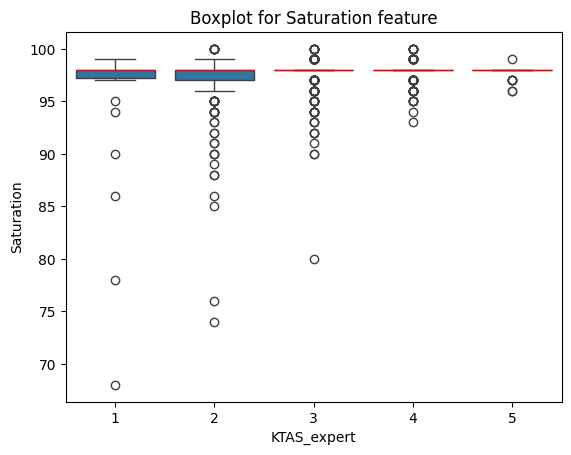

In [41]:
sns.boxplot(x="KTAS_expert", y="Saturation", data=df, medianprops={"color": "red"})
plt.title("Boxplot for Saturation feature")
plt.show()

In [42]:
stats = df.groupby("KTAS_expert")["Saturation"].describe()
outliers = df.groupby("KTAS_expert")["Saturation"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min    25%   50%   75%    max  \
KTAS_expert                                   
1            68.0  97.25  98.0  98.0   99.0   
2            74.0  97.00  98.0  98.0  100.0   
3            80.0  98.00  98.0  98.0  100.0   
4            93.0  98.00  98.0  98.0  100.0   
5            96.0  98.00  98.0  98.0   99.0   

                                                      outliers  
KTAS_expert                                                     
1                         [78.0, 68.0, 94.0, 86.0, 90.0, 95.0]  
2            [95.0, 100.0, 100.0, 88.0, 89.0, 95.0, 92.0, 9...  
3            [97.0, 97.0, 97.0, 95.0, 99.0, 97.0, 99.0, 96....  
4            [100.0, 97.0, 97.0, 100.0, 99.0, 99.0, 99.0, 9...  
5             [97.0, 99.0, 97.0, 97.0, 96.0, 96.0, 97.0, 97.0]  


1. **Median:**
   * For every KTAS level, the value of median stays the same (98%). Since we had a lot of missing data and filled it with the median, the center of each group become identical. The model will learn nothing from the median. It will focus solely on downward deviations and Saturation_is_missing flag.
2. **KTAS 1 and 2:**
   * Minimum value of Saturation in KTAS 1 is 68%, which is an extreme respiratory distress. Values like 68%, 78% or 86% (outliers) are clear signals of life-threatening condition. Minimum value of Saturation in KTAS 2 (74%) is also very low, but slightly higher than in class 1.
   * For KTAS 1 and 2, saturation is the trigger. If Saturation < 90, patient almost automatically is assigned to these categories.
3. **KTAS 3:**
   * A minimum value of 80% suggests that even in the KTAS 3 group, there are patients with low oxygen levels, but their other parameters are likely good enough to avoid being included in KTAS 1 or KTAS 2.
4. **KTAS 4:**
   * This group is stable with safe oxygen levels (93%-100%).
   * Even 97% is an outlier, meaning the norm is very rigid.
5. **KTAS 5:**
   * The narrowest range of all groups (96%-99%).
   * The minimum value is 96% which is the physiological norm for a healthy person.
   * In KTAS 5 there is no room for breathing errors. Every patient here has healthy level of Saturation.

### RR (Respiratory Rate)

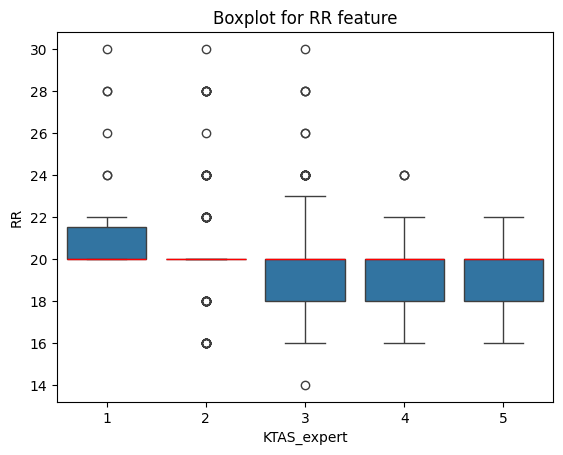

In [43]:
sns.boxplot(x="KTAS_expert", y="RR", data=df, medianprops={"color": "red"})
plt.title("Boxplot for RR feature")
plt.show()

In [44]:
stats = df.groupby("KTAS_expert")["RR"].describe()
outliers = df.groupby("KTAS_expert")["RR"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min   25%   50%   75%   max  \
KTAS_expert                                 
1            20.0  20.0  20.0  21.5  30.0   
2            16.0  20.0  20.0  20.0  30.0   
3            14.0  18.0  20.0  20.0  30.0   
4            16.0  18.0  20.0  20.0  24.0   
5            16.0  18.0  20.0  20.0  22.0   

                                                      outliers  
KTAS_expert                                                     
1                         [28.0, 28.0, 26.0, 30.0, 24.0, 24.0]  
2            [22.0, 22.0, 18.0, 22.0, 18.0, 16.0, 26.0, 24....  
3            [26.0, 24.0, 24.0, 28.0, 24.0, 28.0, 30.0, 24....  
4                                           [24.0, 24.0, 24.0]  
5                                                           []  


1. **KTAS 1:**
   * This is the only group in which the entire lower quartile begins at 20. This means that in this class, there are no patients with healthy respiratory rate (12-20)
2. **KTAS 2:**
   * There are many outliers (up to RR=30).
   * This group is very scattered. There are patients who are still breathing normally, but whose condition is due to other causes, and those who are panting heavily.
   * High-intensity breathing (above 22) is the norm here.
3. **KTAS 3:**
   * Patients in this group do not yet have extremaly poor results (as in KTAS 1), but their parameters are not as ideal and calm as in KTAS 4 and 5.
   * The presence of patients with RR of 30 in this group results from the fact that a single poor result does not make the patient critical if the remaining parameters are normal.
4. **KTAS 4:**
   * The maximum value drops compared to classes 1-3 (from 30 to 24)
   * If the patient is breathing very rapidly, the triage automatically removes them from this category into more urgent groups.
5. **KTAS 5:**
   * Maximum is 22 (just above normal). No outliers.
   * A KTAS 5 patient must be breathing calmly. This parameter almost excludes error- if the RR is high, the patient will definitely not be classified to KTAS 5.

### Age

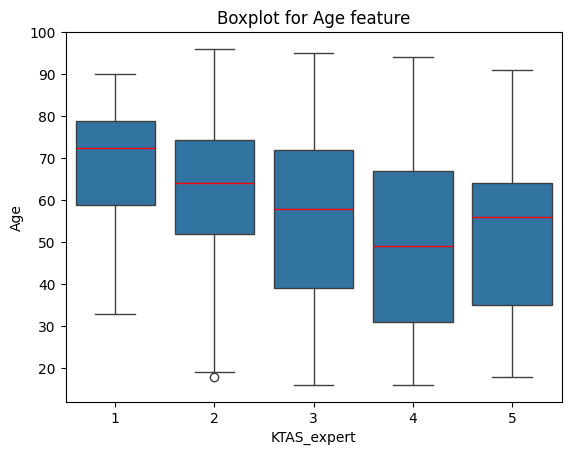

In [45]:
sns.boxplot(x="KTAS_expert", y="Age", data=df, medianprops={"color": "red"})
plt.title("Boxplot for Age feature")
plt.show()

In [46]:
stats = df.groupby("KTAS_expert")["Age"].describe()
outliers = df.groupby("KTAS_expert")["Age"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min    25%   50%    75%   max outliers
KTAS_expert                                         
1            33.0  58.75  72.5  78.75  90.0       []
2            18.0  52.00  64.0  74.25  96.0     [18]
3            16.0  39.00  58.0  72.00  95.0       []
4            16.0  31.00  49.0  67.00  94.0       []
5            18.0  35.00  56.0  64.00  91.0       []


1. **KTAS 1:**
   * This is statistically the oldest group (33-90). The median age is 72.5 years and 25% of the youngest patients in this class are at least 58 years old.
   * Life-threatening conditions (KTAS 1) affect almost exclusively older adults. The youngest patient (33 years old) is an exception to the rule.
2. **KTAS 2:**
    * The median is slightly lower (64) but still high.
    * Outlier (18) is a very interesting point. An 18 year old in KTAS 2 is rare, they must have had very severe symptoms to be assigned such a high priority given this age distribution.
3. **KTAS 3:**
    * The median drops to 58 years of age. There's a significant expansion of the lower quartile (25% of patients are under 39 years old).
    * This is a class where individuals require urgent diagnostics but are statistically healthier than patients in classes 1-2.
4. **KTAS 4:**
   * The lowest median in the entire comparison (49 years). Half of the patients in this group are between 31 and 67 years old.
   * "Milder" cases are the domain of younger people. Their bodies are more resilient, so even in the event of trauma, they are less likely to require top priority.
5. **KTAS 5:**
   * Median age is 56. Although higher than in KTAS 4, 75% of the patients end up at age 64.
   * These are usually stable adults with minor problems.

## BT (Body Temperature)

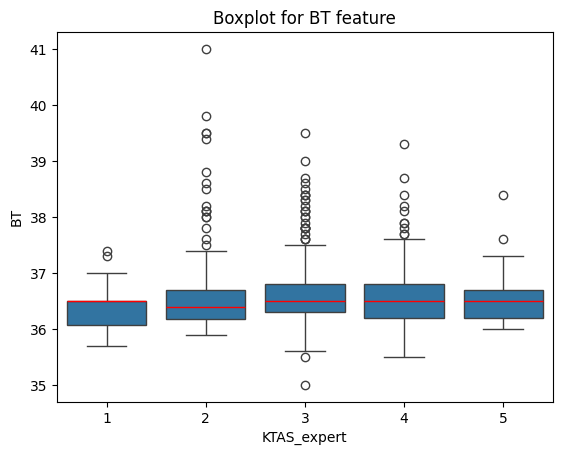

In [47]:
sns.boxplot(x="KTAS_expert", y="BT", data=df, medianprops={"color": "red"})
plt.title("Boxplot for BT feature")
plt.show()

In [48]:
stats = df.groupby("KTAS_expert")["BT"].describe()
outliers = df.groupby("KTAS_expert")["BT"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

              min     25%   50%   75%   max  \
KTAS_expert                                   
1            35.7  36.075  36.5  36.5  37.4   
2            35.9  36.175  36.4  36.7  41.0   
3            35.0  36.300  36.5  36.8  39.5   
4            35.5  36.200  36.5  36.8  39.3   
5            36.0  36.200  36.5  36.7  38.4   

                                                      outliers  
KTAS_expert                                                     
1                                                 [37.4, 37.3]  
2            [38.0, 39.8, 38.1, 38.0, 38.2, 39.4, 38.8, 39....  
3            [38.3, 37.6, 38.2, 38.3, 39.5, 37.8, 38.7, 37....  
4            [38.1, 37.9, 38.2, 39.3, 37.7, 37.9, 37.7, 38....  
5                                                 [38.4, 37.6]  


1. **KTAS 1:**
   * The maximum temperature is 37.4°C. There is not a single case of high fever.
   * Critically ill patients are not admitted to the ER due to high Body Temperature. The model will learn that high fever excludes KTAS 1.
2. **KTAS 2:**
   * The values of temperature ranges between 35.9 and 41.0. This group has the highest values of body temperature.
   * If the temperature exceeds 39°C-40°C, the likelihood of KTAS 2 increases dramatically.
3. **KTAS 3:**
   * This group represents urgent but circulatory stable patients. Although their vital signs often overlap with severe classes (4 and 5), the presence of specific signals (such as for example severe pain or age) makes them categorized correctly
4. **KTAS 4:**
   * Distribution very similiar to KTAS 3, but with fewer extremaly high temperatures.
   * Patients with temperature around 38 are almost evenly distributed between KTAS 3 and 4. Other factors will determine their allocation.
5. **KTAS 5:**
   * Median is 36.5°C and there is no extremes (only two outliers: 38.4°C and 37.6°C)
   * A KTAS 5 patient has a normal body temperature. If someone has a temperature of 39°C they will almost certainly not be assessed as KTAS 5.
   

## NRS_pain

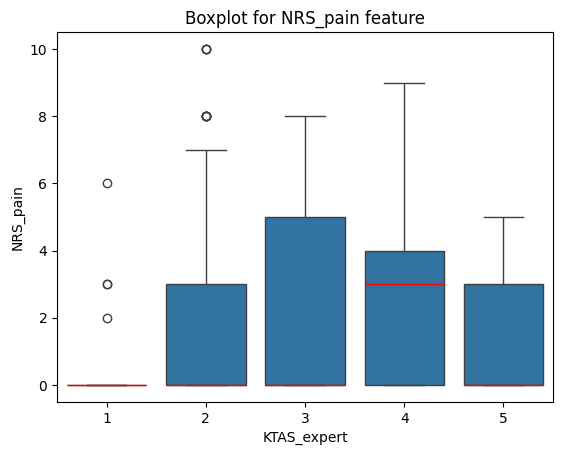

In [49]:
sns.boxplot(x="KTAS_expert", y="NRS_pain", data=df, medianprops={"color": "red"})
plt.title("Boxplot for NRS_pain feature")
plt.show()

In [50]:
stats = df.groupby("KTAS_expert")["NRS_pain"].describe()
outliers = df.groupby("KTAS_expert")["NRS_pain"].apply(get_outliers)

stats["outliers"] = outliers

print(stats[["min", "25%", "50%", "75%", "max", "outliers"]])

             min  25%  50%  75%   max  \
KTAS_expert                             
1            0.0  0.0  0.0  0.0   6.0   
2            0.0  0.0  0.0  3.0  10.0   
3            0.0  0.0  0.0  5.0   8.0   
4            0.0  0.0  3.0  4.0   9.0   
5            0.0  0.0  0.0  3.0   5.0   

                                                outliers  
KTAS_expert                                               
1                                   [3.0, 3.0, 2.0, 6.0]  
2            [8.0, 8.0, 10.0, 8.0, 8.0, 8.0, 10.0, 10.0]  
3                                                     []  
4                                                     []  
5                                                     []  


1. **KTAS 1:**
   * The median and both quartiles (25% and 75%) are 0.0.
   * Critically ill patients (KTAS 1) typically do not report pain. This may be due to them, for example, being unconscious.
   * Values like 6.0 are rare here. If a KTAS 1 patient feels pain, they are an exception to the "unconscious patient" rule.
2. **KTAS 2:**
   * Pain extremes (0.0 - 10.0). This groups includes the highest score in the entire set (10.0).
   * Here, the pain is severe enough to raise the priority to level 2 on its own.
3. **KTAS 3:**
   * The median is still 0.0 but the 75% quartile indicates 5.0.
   * These are patients who are in pain, but their vital signs are still stable. The patient is in pain, but not yet enough to be considered KTAS 2.
4. **KTAS 4:**
   * This is the only group with a median of 3.0. Moreover, 75% of patients have a pain level of 4.0.
   * KTAS 4 patients are often individuals with minor injuries, who are fully aware. Because they have no other symptoms, they can rate their pain aloud and clearly.
   * These patients are suffering, but safe.
5. **KTAS 5:**
   * Low range: max - 5.0, median = 0.0.
   * Patients with the lowest priority are typically those experiencing no or minimal pain. 

## Stacked Bar Chart for Categorical Features

In [51]:
arrival_cols = ["Arrival_2", "Arrival_3", "Arrival_4", "Arrival_5"]

df["Arrival_mode"] = df[arrival_cols].idxmax(axis=1)
df["Arrival_mode"] = df["Arrival_mode"].str.replace("Arrival_", "").astype(int)

mask_all_false = df[arrival_cols].sum(axis=1) == 0
df.loc[mask_all_false, "Arrival_mode"] = 1

In [52]:
ct = pd.crosstab(df["Arrival_mode"], df["KTAS_expert"], normalize="index")

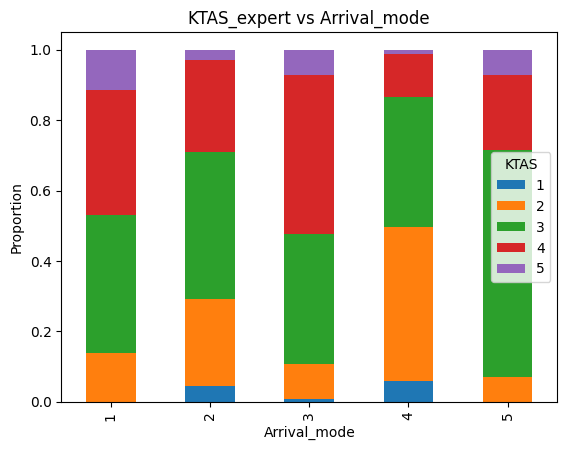

In [53]:
ct.plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.title("KTAS_expert vs Arrival_mode")
plt.legend(title="KTAS")
plt.show()

1 = Walking, 2 = Public Ambulance, 3 = Private Vehicle, 4 = Private Ambulance, 5 = Other

* Most patients assigned to **KTAS 1** group arrived by Private Vehicle or Private Ambulance.
* Patients assigned to **KTAS 2** group arrived by Private Vehicle in most cases.
* Most patients assigned to **KTAS 3** group arrived by Private Ambulance.
* Most patients assigned to **KTAS 4** group arrived by Public Ambulance.
* Patients assigned to **KTAS 5** group arrived by Private Vehicle in most cases.

In [54]:
df = df.drop("Arrival_mode", axis=1)

## Relations between Chief Complain and KTAS_expert

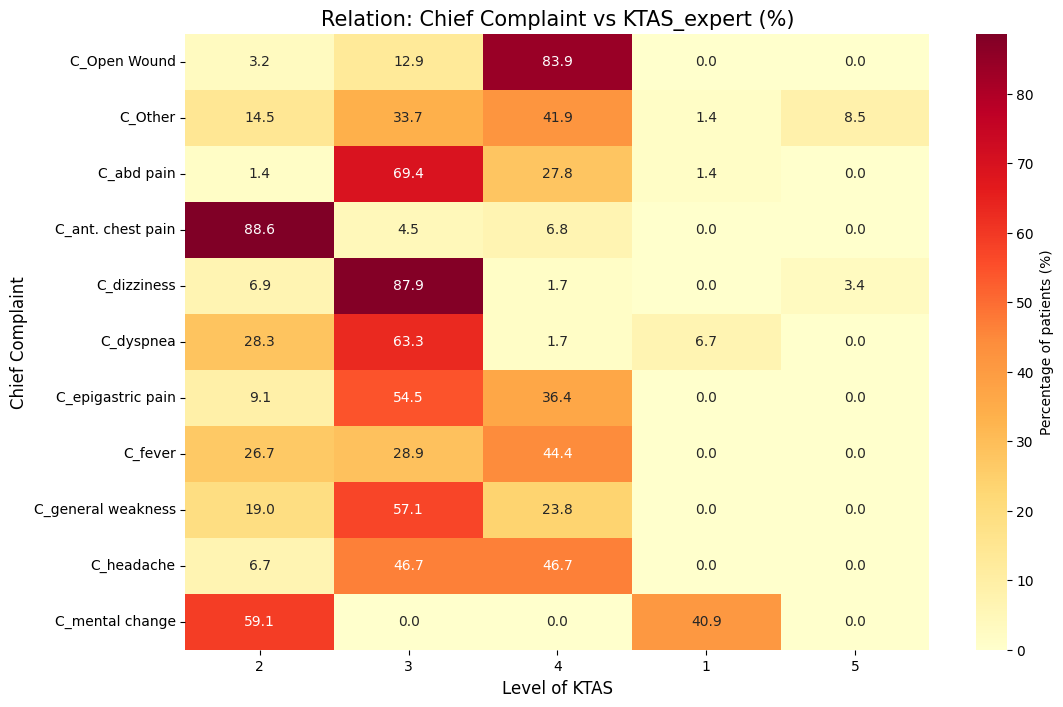

In [55]:
complaint_cols = [col for col in df.columns if col.startswith("C_")]

analysis = []

for col in complaint_cols:
    temp = df[df[col] == 1]["KTAS_expert"].value_counts(normalize=True).sort_index() * 100
    temp.name = col
    analysis.append(temp)

pivot_complaints = pd.concat(analysis, axis=1).T.fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_complaints, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Percentage of patients (%)'})
plt.title("Relation: Chief Complaint vs KTAS_expert (%)", fontsize=15)
plt.xlabel("Level of KTAS", fontsize=12)
plt.ylabel("Chief Complaint", fontsize=12)
plt.show()

1. **KTAS 1 and KTAS 2:**
   * C_mental change is the most alarming symptom. 40.9% of the patients are assigned to KTAS 1, and the remaining 59.1% to KTAS 2. 0% of these patients end up in classes 3,4 or 5.
   * C_and. chest pain: Nearly 89% of these patients are assigned to KTAS 2. Chest pain is the priority until proven otherwise.
2. **KTAS 3:**
    * C_dizziness: 87.9% of patients with this symptom end up in KTAS 3. Patient with dizziness require diagnosis, but is rarely in an immediate life-threatening condition.
    * C_abd pain: Nearly 70% of patients with this symptom end up in KTAS 3. These are patients requiring imaging and laboratory tests, which perfectly defines the "urgent but stable" class.
    * C_dyspnea: The majority (63.3%) goes to KTAS 3, 28.3% to KTAS 3, and 6.7% to KTAS 1. It shows that dyspnea is a floating symptom. The vital parameters will decide whether the patient will go to KTAS 1/2/3/4.
3. **KTAS 4 and KTAS 5:**
   * C_Open wound: Predominant in KTAS 4 (83.9%). The patient is stable and does not require complex internal diagnostics.
   * C_Headache: This symptom is evenly distributed between KTAS 3 and KTAS 4 (the model will have to check other symptoms to dermine whether a patient needs to be assigned to KTAS 3 or 4).

## Model training
### splitting the data

In [56]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [57]:
X = df.drop(columns=["KTAS_expert"])
y = df["KTAS_expert"]

In [58]:
#label encoding for xgboost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [59]:
#stratified division
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### SMOTE
Why are we using SMOTE (Synthetic Minority Over-sampling Technique)?
- There is a huge imbalance in data. Critically ill patients (KTAS 1) are only 2% of the data, while stable patients (KTAS 3 and KTAS 4) are about 75% of the data.
- Standard alogirithms strive for the highest overall accuracy. If the model simply assigned each patient KTAS 3 or 4 it would achieve high accuracy, even though it would completely ignore dying individuals.
- SMOTE not only replicates rare cases but also creates new, synthetic examples of KTAS 1 nad KTAS 5 patients by analyzing the characteristics of existing ones.
- As a result, the training seet becomes balanced. The model "sees" as many deaths as colds.

In [60]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### models (random forest and xgboost)

In [61]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

In [62]:
rf_model = RandomForestClassifier(
    class_weight="balanced_subsample",
    max_depth=10,
    min_samples_split=5,
    n_estimators=300,
    random_state=42
)

In [63]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [64]:
final_model = VotingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    voting="soft"
)

Why are we using **VotingClassifier**?

VotingClassifier combines two completely different approaches to data, which work better together. It makes the model decision less susceptible to single algorithm errors.

* **Random Forest:** builds multiple deep trees independently. Its great at discovering general rules and is less susceptible to momentary trends in the data.
* **XGBoost:** builds trees sequentially, with each tree correcting the errors of the previous one. It is precise in finding difficult nonlinear relationships.

### training the final model

In [65]:
final_model.fit(X_train_resampled, y_train_resampled)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [66]:
y_pred = final_model.predict(X_test)

In [67]:
import joblib
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

## Evaluation

### classification report

In [68]:
from sklearn.metrics import classification_report, confusion_matrix

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['KTAS 1', 'KTAS 2', 'KTAS 3', 'KTAS 4', 'KTAS 5']))

              precision    recall  f1-score   support

      KTAS 1       0.80      0.80      0.80         5
      KTAS 2       0.53      0.52      0.53        44
      KTAS 3       0.71      0.70      0.71        98
      KTAS 4       0.75      0.71      0.73        92
      KTAS 5       0.27      0.40      0.32        15

    accuracy                           0.66       254
   macro avg       0.61      0.63      0.62       254
weighted avg       0.67      0.66      0.66       254



**KTAS 1:**
* **Precision (0.80):** 4 out of 5 times the model predicts "KTAS 1" it is correct.
* **Recall (0.80):** Of the 5 critically ill patients model correctly identified 4.

**KTAS 2:**
* **Precision (0.53):** When the model predicts KTAS 2, it is only correct half the time.
* **Recall (0.52):** The model detects only half of the patients who require immediate attention. The remaining 48% are delegated to different category.

**KTAS 3 and KTAS 4:**
* **Precision (0.71-0.75):** When the model precits KTAS 3 or KTAS 4, it is correct in 71-75% of cases.
* **Recall (0.70-0.71):** The model consistently captures approximately 70% of these patients.

**KTAS 5:**
* **Precision (0.27):** Very low. Most patients identified as "KTAS 5" actually belonged to higher (more severe) groups.
* **Recall (0.40):** The model finds fewer than half of the patients who could safely wait the longest.

**Aggregate Metrics**
* **Accuracy (0.66):** 66% accurate diagnoses. It's a decent result, but model will require human supervision.
* **Macro Avg (0.62 F1-score):** An average that treats KTAS 1 (support=5) as important as KTAS 3 (support=98). The model has not become ignorant of rare cases.
* **Weighted Avg (0.66 F1-score):** Average weighted by the class distribution. This is close to accuracy, suggesting that the model does not experience significant performance jumps between large and small groups (except for class 5).




### confusion matrix

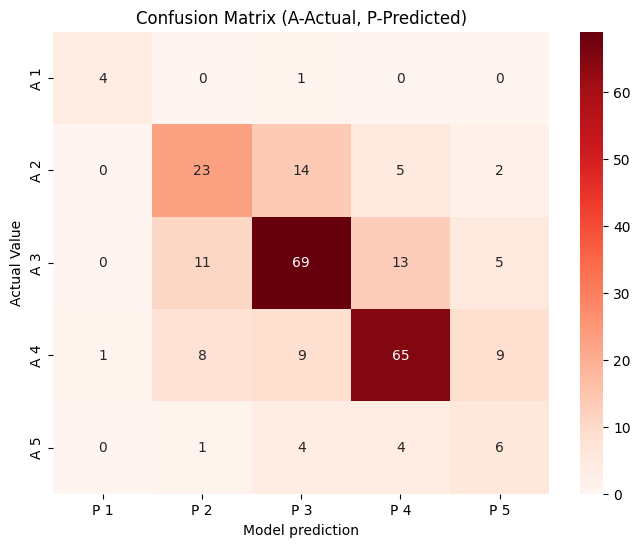

In [70]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['P 1', 'P 2', 'P 3', 'P 4', 'P 5'], 
            yticklabels=['A 1', 'A 2', 'A 3', 'A 4', 'A 5'])
plt.title('Confusion Matrix (A-Actual, P-Predicted)')
plt.ylabel('Actual Value')
plt.xlabel('Model prediction')
plt.show()

* **KTAS 1:** Out of 5 patients, 4 were diagnosed perfectly. One patient was considered KTAS 3.
  * Moving from 1 to 3 is risky. What parameters did the patient have that model decided that he belonged to KTAS 3?
* **KTAS 2:** Out of 44 patients, 23 were correctly assigned to KTAS 2. However, 14 patients were "downgraded" to KTAS 3, and 7 to even lower categories (4 and 5).
    * The model tends to be optimistic in severe cases. Nearly half of the patients in group 2 would have received care later than the standard requires.
* **KTAS 3:** 69 correct matches out of 98. The model most often confuses KTAS 3 with KTAS 4 (13 patients).
    * These are "safe" errors. The difference between KTAS 3 and KTAS 4 is often fluid and depends on subjective pain assessment.
* **KTAS 4:** 65 correct matches out of 92. The model "promoted" 8 patients from group 4 to group 2 (Over-triage).
  * This is beneficial for safety (it's better to check someone faster), but creates unnecessary burden for the emergency staff.
* **KTAS 5:** Only 6 out of 15 patients were correctly identified. The model identified 9 patients from this group as requiring more immediete attention.
    * The model is afraid of KTAS 5. It became very sensitive and preffered to assign someone a KTAS 4 rather than risk the lowest category.

### balanced accuracy score

In [71]:
from sklearn.metrics import balanced_accuracy_score

In [72]:
b_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy score: {b_acc:.2%}")

Balanced accuracy score: 62.67%


Balanced accuracy score averages the accuracy for each class individually, ignoring their size, so the score of 62.67 is the most reliable measure of the model's overall perfomance. Unlike the standard accuracy score, this metric confirms that the model is actually learning to recognize rare critical ilnesses (KTAS 1) rather than relying solely on the dominant stable patient population. 

### critical under-triage

In [73]:
import numpy as np

In [74]:
def critical_undertriage(y_true, y_pred):
    urgent = y_true <= 2
    critical_errors = np.sum(urgent & (y_pred >= 4))

    return critical_errors / np.sum(urgent)

ut_rate = critical_undertriage(y_test + 1, y_pred + 1)
print(f"Critical under-triage: {ut_rate:.2%}")

Critical under-triage: 14.29%


A critical under-triage rate of 14.29% means that statistically, one in seven critically ill patients (KTAS 1-2) would be incorrectly considered non-urgent. From a medical perspective, this is the highest-risk error, as it directly delays life-saving intervention. This result defines the model's current role as a decision support system rather than a standalone tool, requiring staff review on case-by-case basis. Further project development should focus on calibrating decision thresholds to minimize this risk at the expense of an acceptable increase in redundant alarms (over-triage).

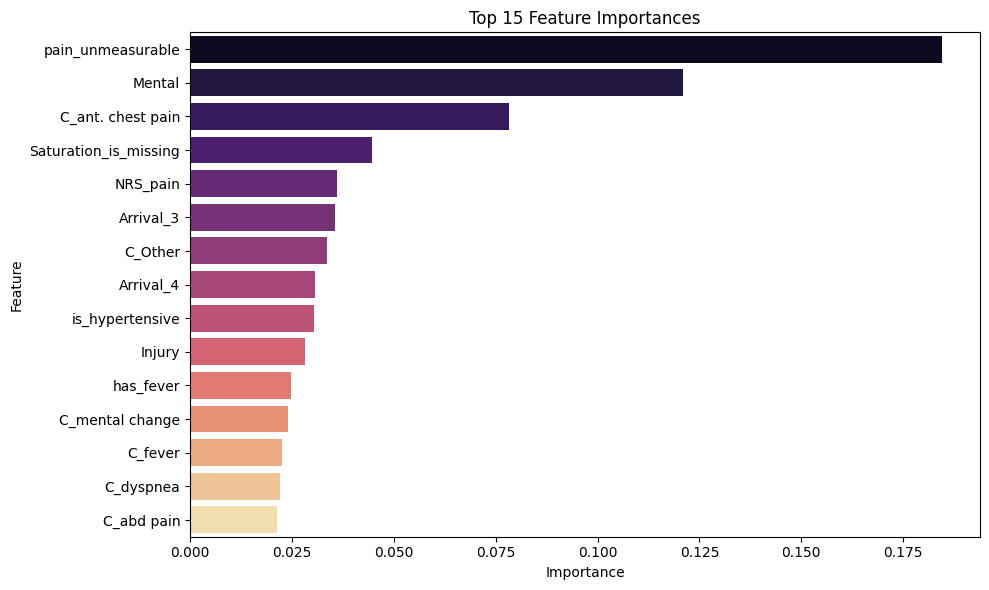

In [75]:
xgb_model = final_model.named_estimators_['xgb']

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": xgb_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

**Critical Condition Indicators**
* pain_unmeasurable (18.4%) and Mental (12.1%) are the two strongest predictors in the entire model. Their high rankings indicate that the model has correctly learned a fundamental triage principle: an inability to contact the patient or an unconscious patient signals the highest risk of death and if the staff is unable to assess pain, the model automatically assigns a hight priority.
* C_ant. chec pain is the thrid most important characteristic. This is consistent with medical protocols - any such pain must be treated as a potential heart attack until ruled out, which the model perfectly reflects.
  
**Intermediate Signals and "Missing" data**
* Saturation_is_missing (4.5%) is also important to the model. The fact that saturation was not measured is more important to the model than many other symptoms. Missing measurement often indicates extremes: either the patient is in such good condition that the measurement was omitted (KTAS 5), or in such poor condition that immediate resuscitation was a priority.
* Arrival_3 (3,5%). A method of transport is significant indicator of stability. The model observed that the patients who arrived at the hospital on their own are statistically less likely to require immediate intervention.
  
**Vital Signs and Symptoms**
* is_hypertensive (3.0%) and NRS_pain (3.6%). Although vital signs are important the model treats them as a supplement to the indicators that are more critical. High pain (NRS) alone moves patient up the scale but rarely alone determines KTAS 1 status. 


## SHAP

In [76]:
import shap

Analysis for patient with index 3
Model predicted: KTAS 1


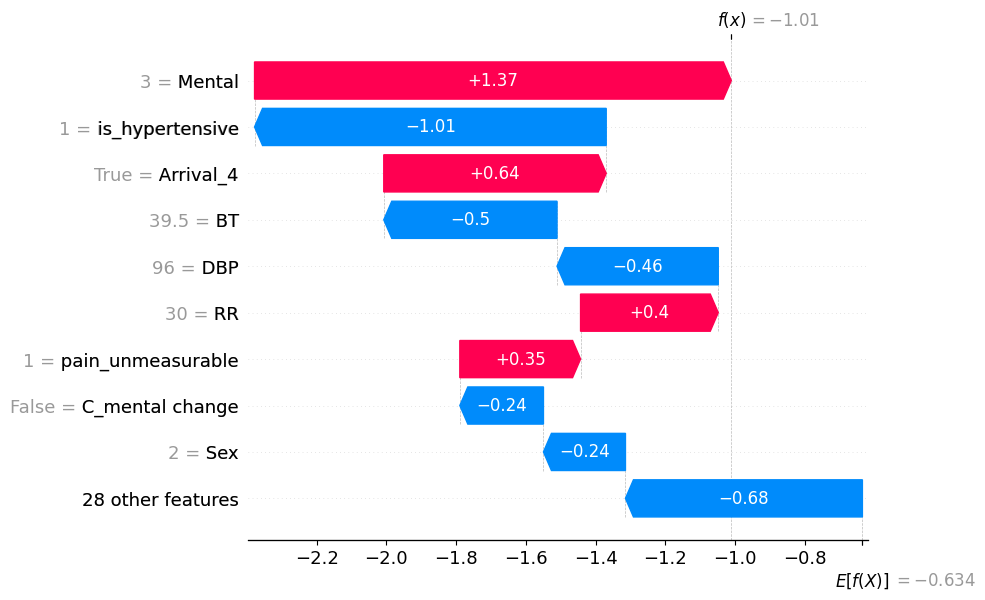

In [77]:
xgb_model = final_model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_model)

patient_index = 3
patient_data = X_test.iloc[[patient_index]]

shap_values_patient = explainer(patient_data)

predicted_class = final_model.predict(patient_data)[0]


class_idx = int(predicted_class) - 1 

print(f"Analysis for patient with index {patient_index}")
print(f"Model predicted: KTAS {predicted_class}")

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values_patient[0, :, class_idx])
plt.show()

### SHAP Waterfall Plot Interpretation (Patient Index 3)

This waterfall plot explains how the machine learning model arrived at its prediction for a specific patient (**Index 3**). The model predicted a triage level of **KTAS 1** (representing the highest level of urgency).

#### Starting and Ending Points (X-axis)
* **E[f(X)] = -0.634 (bottom right):** This is the base value (expected value). It represents the average prediction of the model across the entire dataset before looking at this specific patient's features.
* **f(x) = -1.01 (top right):** This is the final prediction output by the model for this specific patient. The entire journey from -0.634 to -1.01 is the sum of the effects of all the colored bars.

#### Bar Colors and Directions (Feature Impact)
SHAP values show both the strength and direction of a feature's influence:
* **Red bars (right, positive values):** Features that increase the model's output value.
* **Blue bars (left, negative values):** Features that decrease the model's output value.

#### Analysis of Key Features (Top to Bottom)
* **3 = Mental (+1.37):** The patient's mental/consciousness status at level 3 had the strongest positive impact, pushing the prediction significantly to the right.
* **1 = is_hypertensive (-1.01):** The fact that the patient is hypertensive (value 1) had a very strong decreasing impact on the final score.
* **True = Arrival_4 (+0.64):** The specific arrival (Arrival_4 = True) increased the score.
* **39.5 = BT (-0.5):** A body temperature of 39.5°C (high fever) contributed to lowering the score.
* **96 = DBP (-0.46):** A Diastolic Blood Pressure of 96 mm Hg lowered the score.
* **30 = RR (+0.4):** A Respiratory Rate of 30 breaths per minute (indicating tachypnea/rapid breathing) increased the score.
* **1 = pain_unmeasurable (+0.35):** The patient having unmeasurable pain (often due to altered mental status or unconsciousness) increased the score.
* **Other features:** The absence of acute mental changes (C_mental change = False, sex Sex = 2), and the combined effect of 28 other features (-0.68) all pushed the prediction further into the negative.

In [78]:
for col in X.columns:
    print(f"\nKolumna: {col}")
    print(df[col].unique())


Kolumna: Sex
[2 1]

Kolumna: Age
[71 56 68 58 54 49 78 32 38 43 45 53 55 65 69 20 79 24 59 77 37 62 74 44
 16 19 27 30 47 48 87 21 34 36 52 70 81 89 39 29 64 72 83 23 25 26 22 82
 33 61 75 18 42 66 76 85 73 84 50 28 60 67 80 90 92 57 88 63 35 46 17 31
 40 41 51 86 94 91 93 95 96]

Kolumna: Patients number per hour
[ 3 12  8  4  6 11 14 10  9  2  5  7  1 17 15 13]

Kolumna: Injury
[2 1]

Kolumna: Mental
[1 2 3 4]

Kolumna: NRS_pain
[ 2.  3.  4.  5.  6.  8.  9.  0.  1.  7. 10.]

Kolumna: SBP
[160. 137. 130. 139.  91. 140. 110. 169. 148. 141. 120. 121. 135. 100.
 133. 124. 118.  80. 180. 125. 162. 116. 152. 164. 196. 144. 150. 200.
 113. 119. 156. 165. 132. 199. 138. 176. 170. 136. 194. 122. 214. 178.
 108.  50. 145. 142. 210. 143.  65. 129. 123. 158. 187.  96.  70. 102.
 161.  90. 105. 190. 151. 134. 106. 149. 189. 197. 155. 131. 168. 166.
 126. 115. 128. 114. 153. 117. 101. 159. 109. 157. 182. 111. 163. 167.
 127. 147. 154. 112. 179. 191.  93.  98. 198. 204. 177. 195. 107. 171.
 183. 1

In [79]:
X_train.columns

Index(['Sex', 'Age', 'Patients number per hour', 'Injury', 'Mental',
       'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation',
       'C_Open Wound', 'C_Other', 'C_abd pain', 'C_ant. chest pain',
       'C_dizziness', 'C_dyspnea', 'C_epigastric pain', 'C_fever',
       'C_general weakness', 'C_headache', 'C_mental change',
       'Saturation_is_missing', 'pain_unmeasurable', 'Arrival_2', 'Arrival_3',
       'Arrival_4', 'Arrival_5', 'is_hypotensive', 'is_hypertensive',
       'has_fever', 'low_oxygen', 'tachycardia', 'bradycardia', 'shock_index',
       'map'],
      dtype='str')

In [81]:
X_train

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable,Arrival_2,Arrival_3,Arrival_4,Arrival_5,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
767,1,59,9,1,1,0.0,120.0,81.0,63.0,16.0,36.8,98.0,False,True,False,False,False,False,False,False,False,False,False,1,0,False,True,False,False,0,0,0,0,0,0,0.525000,94.000000
35,1,27,3,1,1,0.0,120.0,80.0,84.0,20.0,36.8,97.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,True,False,False,0,0,0,0,0,0,0.700000,93.333333
1182,1,81,2,1,3,0.0,100.0,60.0,100.0,24.0,36.4,94.0,False,False,False,False,False,True,False,False,False,False,False,0,1,False,False,True,False,0,0,0,0,0,0,1.000000,73.333333
797,2,70,5,1,1,0.0,94.0,54.0,85.0,18.0,35.0,98.0,False,False,False,False,True,False,False,False,False,False,False,1,0,True,False,False,False,1,0,0,0,0,0,0.904255,67.333333
481,1,33,12,2,1,4.0,112.0,72.0,56.0,20.0,36.9,98.0,False,True,False,False,False,False,False,False,False,False,False,1,0,False,True,False,False,0,0,0,0,0,1,0.500000,85.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,1,24,13,1,1,0.0,120.0,75.0,84.0,16.0,36.9,98.0,False,True,False,False,False,False,False,False,False,False,False,1,0,False,True,False,False,0,0,0,0,0,0,0.700000,90.000000
119,2,54,7,1,1,10.0,152.0,96.0,50.0,16.0,36.7,98.0,False,True,False,False,False,False,False,False,False,False,False,1,0,False,True,False,False,0,1,0,0,0,1,0.328947,114.666667
169,1,79,11,1,1,0.0,160.0,100.0,64.0,20.0,36.5,94.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,False,True,False,0,1,0,0,0,0,0.400000,120.000000
413,2,74,10,2,1,3.0,100.0,60.0,72.0,18.0,36.6,97.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,True,False,False,0,0,0,0,0,0,0.720000,73.333333


In [82]:
X_test

,Sex,Age,Patients number per hour,Injury,Mental,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,C_Open Wound,C_Other,C_abd pain,C_ant. chest pain,C_dizziness,C_dyspnea,C_epigastric pain,C_fever,C_general weakness,C_headache,C_mental change,Saturation_is_missing,pain_unmeasurable,Arrival_2,Arrival_3,Arrival_4,Arrival_5,is_hypotensive,is_hypertensive,has_fever,low_oxygen,tachycardia,bradycardia,shock_index,map
135,1,34,5,1,1,0.0,129.0,94.0,120.0,18.0,36.5,98.0,False,False,False,False,False,False,False,False,True,False,False,1,0,True,False,False,False,0,1,0,0,1,0,0.930233,105.666667
1194,1,84,10,1,1,0.0,150.0,100.0,100.0,20.0,36.6,96.0,False,True,False,False,False,False,False,False,False,False,False,0,0,True,False,False,False,0,1,0,0,0,0,0.666667,116.666667
1087,1,69,10,1,1,0.0,156.0,85.0,72.0,20.0,36.6,98.0,False,False,False,False,True,False,False,False,False,False,False,1,0,True,False,False,False,0,1,0,0,0,0,0.461538,108.666667
788,2,47,7,1,3,0.0,139.0,96.0,114.0,30.0,39.5,98.0,False,False,False,False,False,False,False,True,False,False,False,1,1,False,False,True,False,0,1,1,0,1,0,0.820144,110.333333
1112,1,72,7,1,1,0.0,120.0,70.0,60.0,20.0,36.3,99.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,False,True,False,0,0,0,0,0,0,0.500000,86.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1021,1,60,8,1,1,0.0,120.0,80.0,76.0,20.0,36.3,98.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,True,False,False,0,0,0,0,0,0,0.633333,93.333333
759,1,83,5,1,1,0.0,164.0,65.0,88.0,20.0,36.7,98.0,False,False,False,False,False,True,False,False,False,False,False,1,0,True,False,False,False,0,1,0,0,0,0,0.536585,98.000000
890,2,34,4,1,1,0.0,156.0,96.0,123.0,18.0,36.5,98.0,False,True,False,False,False,False,False,False,False,False,False,1,0,True,False,False,False,0,1,0,0,1,0,0.788462,116.000000
270,2,29,8,2,1,3.0,100.0,60.0,86.0,20.0,36.3,99.0,False,True,False,False,False,False,False,False,False,False,False,0,0,False,True,False,False,0,0,0,0,0,0,0.860000,73.333333
